## step classifcation
* 1- split data to train & test
* 2- build classifcation model(randomforest classifer)
* 3- evalution model

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix , classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
import joblib


In [2]:
rfm_segmentation = pd.read_csv('rfm_table_with_segments.csv')
rfm_segmentation.head()

,Recency,Frequency,Monetary,Segment
0,325,1,77183.60,Active valuable
1,1,7,4310.00,Occasional
2,74,4,1797.24,Occasional
3,18,1,1757.55,Occasional
4,309,1,334.40,Churned


In [3]:
rfm_segmentation.shape

(4338, 4)

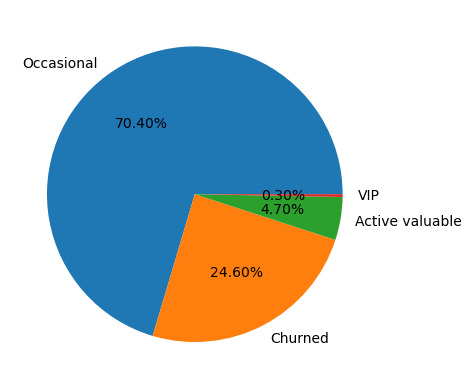

In [4]:
plt.pie(x=rfm_segmentation['Segment'].value_counts().values , labels=rfm_segmentation['Segment'].value_counts().index , autopct='%.2f%%')
plt.show()

* 1- split data to train & test


In [5]:
feautures = rfm_segmentation.drop('Segment', axis=1)
labels = rfm_segmentation['Segment']

In [6]:
x_train , x_test , y_train , y_test = train_test_split(feautures, labels, test_size=0.2,stratify=labels, random_state=42)

In [7]:

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

  File "c:\Users\lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\lenovo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lenovo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lenovo\anaconda3\Lib\subproc

In [8]:
print(y_train.value_counts())
print(y_train_resampled.value_counts())

Segment
Occasional         2443
Churned             854
Active valuable     163
VIP                  10
Name: count, dtype: int64
Segment
Occasional         2443
Churned            2443
Active valuable    2443
VIP                2443
Name: count, dtype: int64


* 2- build classifcation model

In [9]:
log_model = RandomForestClassifier(class_weight='balanced',random_state=42)
log_model.fit(X_train_resampled , y_train_resampled)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [10]:
y_pred = log_model.predict(x_test)
print(y_pred[:10])

['Occasional' 'Occasional' 'Churned' 'Occasional' 'Occasional'
 'Occasional' 'Occasional' 'Occasional' 'Occasional' 'Occasional']


* 3- evalution model

<Axes: >

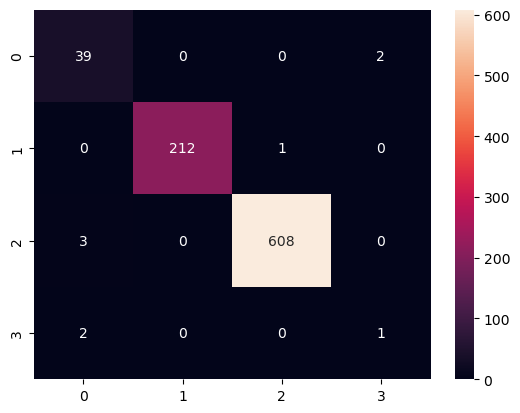

In [11]:
cm = confusion_matrix(y_test , y_pred)

sns.heatmap(cm , annot=True ,fmt='d' )

In [12]:
print(classification_report(y_test , y_pred))

                 precision    recall  f1-score   support

Active valuable       0.89      0.95      0.92        41
        Churned       1.00      1.00      1.00       213
     Occasional       1.00      1.00      1.00       611
            VIP       0.33      0.33      0.33         3

       accuracy                           0.99       868
      macro avg       0.80      0.82      0.81       868
   weighted avg       0.99      0.99      0.99       868



In [13]:
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
x_test = scaler.transform(x_test)

In [14]:
log_model = LogisticRegression()
log_model.fit(X_train_resampled , y_train_resampled)

LogisticRegression()

In [15]:
y_pred1 = log_model.predict(x_test)
y_pred1[:10]

array(['Occasional', 'Occasional', 'Churned', 'Occasional', 'Occasional',
       'Occasional', 'Occasional', 'Occasional', 'Occasional',
       'Occasional'], dtype=object)

<Axes: >

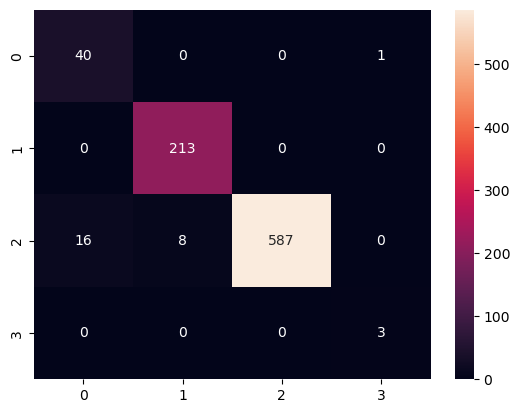

In [16]:
cm1 = confusion_matrix(y_test , y_pred1)
sns.heatmap(cm1 , annot=True ,fmt='d' )

In [17]:
print(classification_report(y_test , y_pred1))

                 precision    recall  f1-score   support

Active valuable       0.71      0.98      0.82        41
        Churned       0.96      1.00      0.98       213
     Occasional       1.00      0.96      0.98       611
            VIP       0.75      1.00      0.86         3

       accuracy                           0.97       868
      macro avg       0.86      0.98      0.91       868
   weighted avg       0.98      0.97      0.97       868



In [18]:
joblib.dump(log_model, "model_class.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']